<a href="https://colab.research.google.com/github/haleemaasadiya01/Seasonal-Agriculture-Performance/blob/main/Haleema_MajorProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Analysis

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)

## Load the Dataset

In [ ]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


## Data Cleaning

In [ ]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0


We found missing values in `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha`.
Instead of dropping these rows (which would lose data from other columns), we fill them with the **mean value for that Season** (and Crop, for Yield) — this keeps the seasonal pattern intact rather than skewing it with an overall average.

In [ ]:
# Fill missing Rainfall and Soil Moisture with season-wise mean
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df.groupby('Season')['Rainfall_mm'].transform('mean'))
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df.groupby('Season')['Soil_Moisture_pct'].transform('mean'))

# Fill missing Yield with season+crop-wise mean (yield depends heavily on crop type)
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].transform('mean')
)

print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


In [ ]:
# Sanity checks for impossible values
print("Negative Yield:", (df['Yield_Tonnes_Ha'] < 0).sum())
print("Non-positive Farm Area:", (df['Farm_Area_Hectares'] <= 0).sum())
print("Humidity above 100%:", (df['Humidity_pct'] > 100).sum())
print("Negative Rainfall:", (df['Rainfall_mm'] < 0).sum())

Negative Yield: 0
Non-positive Farm Area: 0
Humidity above 100%: 0
Negative Rainfall: 0


In [ ]:
df.to_csv('seasonal_agriculture_cleaned.csv', index=False)

In [ ]:
from google.colab import files
files.download('seasonal_agriculture_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Univariate Exploration

/tmp/ipykernel_552/2491156723.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Season', order=df['Season'].value_counts().index, ax=axes[0,0], palette='viridis')
/tmp/ipykernel_552/2491156723.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Crop', order=df['Crop'].value_counts().index, ax=axes[0,1], palette='crest')
/tmp/ipykernel_552/2491156723.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Irrigation_Method', order=df['Irrigation_Method'].value_counts().index, ax=axes[1,0], palette='flar

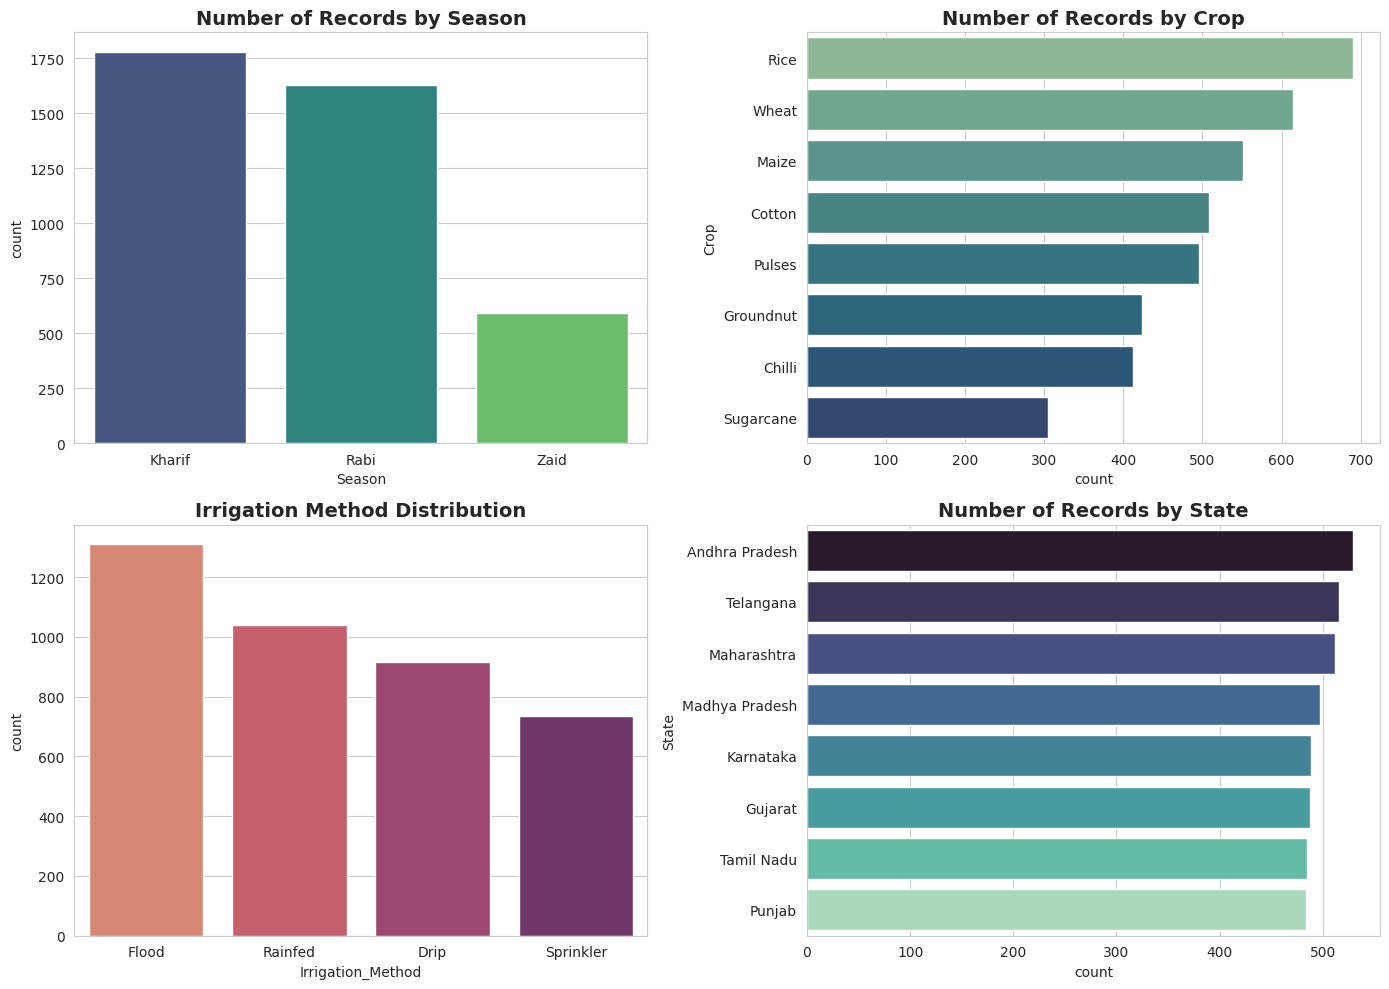

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='Season', order=df['Season'].value_counts().index, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Number of Records by Season')

sns.countplot(data=df, y='Crop', order=df['Crop'].value_counts().index, ax=axes[0,1], palette='crest')
axes[0,1].set_title('Number of Records by Crop')

sns.countplot(data=df, x='Irrigation_Method', order=df['Irrigation_Method'].value_counts().index, ax=axes[1,0], palette='flare')
axes[1,0].set_title('Irrigation Method Distribution')

sns.countplot(data=df, y='State', order=df['State'].value_counts().index, ax=axes[1,1], palette='mako')
axes[1,1].set_title('Number of Records by State')

plt.tight_layout()
plt.savefig('01_univariate_overview.png', dpi=150)
plt.show()

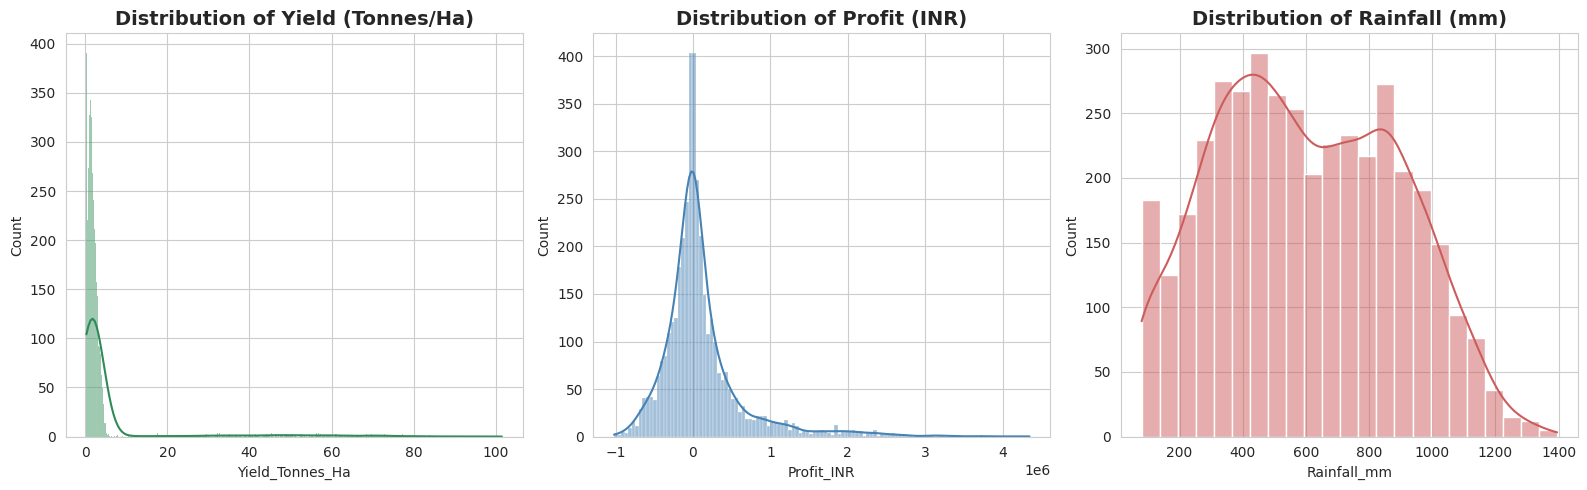

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.histplot(df['Yield_Tonnes_Ha'], kde=True, ax=axes[0], color='seagreen')
axes[0].set_title('Distribution of Yield (Tonnes/Ha)')

sns.histplot(df['Profit_INR'], kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Distribution of Profit (INR)')

sns.histplot(df['Rainfall_mm'], kde=True, ax=axes[2], color='indianred')
axes[2].set_title('Distribution of Rainfall (mm)')

plt.tight_layout()
plt.savefig('02_key_distributions.png', dpi=150)
plt.show()

## Seasonal Performance Comparison (Core Analysis)

In [ ]:
season_summary = df.groupby('Season')[[
    'Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Avg_Temperature_C',
    'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'
]].mean().round(2)

season_summary

,Yield_Tonnes_Ha,Profit_INR,Rainfall_mm,Avg_Temperature_C,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.63,178914.65,852.08,28.45,6102.20,5.89,54.47
Rabi,5.09,87689.47,436.00,23.49,5846.99,5.19,40.48
Zaid,4.64,-24804.82,299.42,31.04,6419.89,4.41,38.22


/tmp/ipykernel_552/3325230620.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=metric, ax=ax, estimator='mean', errorbar=None, palette='Set2')
/tmp/ipykernel_552/3325230620.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=metric, ax=ax, estimator='mean', errorbar=None, palette='Set2')
/tmp/ipykernel_552/3325230620.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=metric, ax=ax, estimator='mean', errorbar=None, palette='Set2')
/tmp/ipykernel_552/3325230620.py:6: Futu

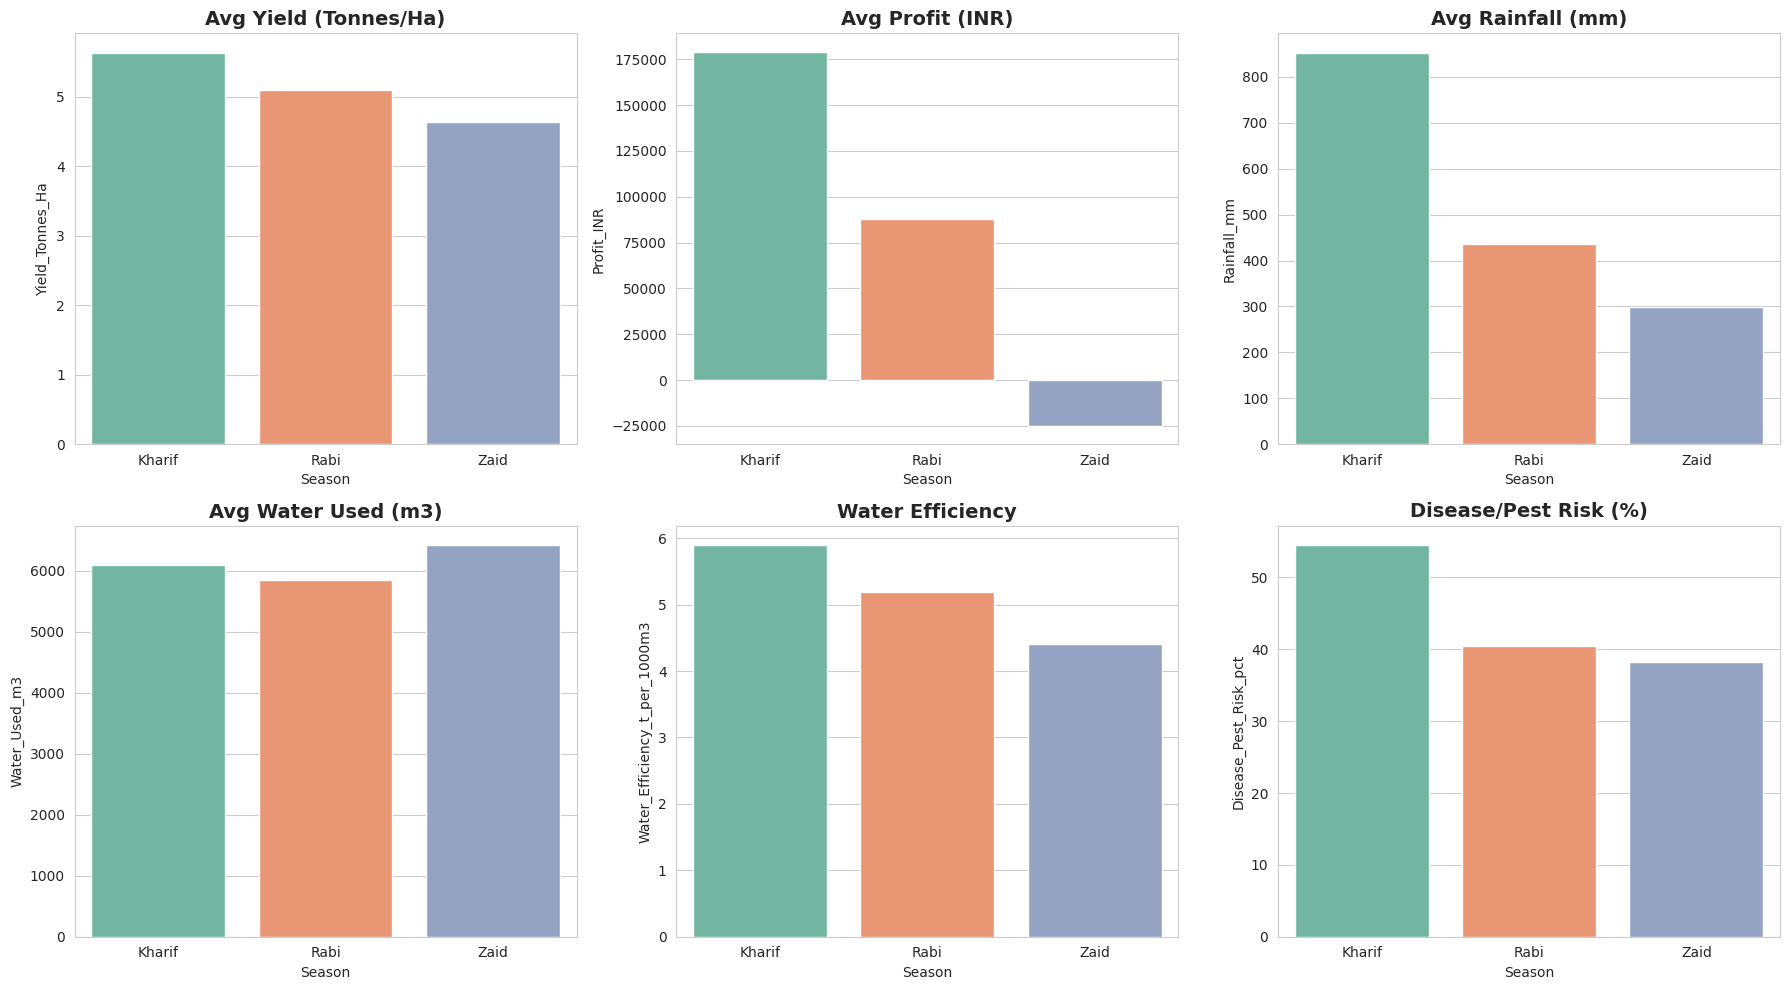

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = ['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
titles = ['Avg Yield (Tonnes/Ha)', 'Avg Profit (INR)', 'Avg Rainfall (mm)', 'Avg Water Used (m3)', 'Water Efficiency', 'Disease/Pest Risk (%)']

for ax, metric, title in zip(axes.flat, metrics, titles):
    sns.barplot(data=df, x='Season', y=metric, ax=ax, estimator='mean', errorbar=None, palette='Set2')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('03_seasonal_metrics_comparison.png', dpi=150)
plt.show()

## Which Crop Performs Best in Which Season?

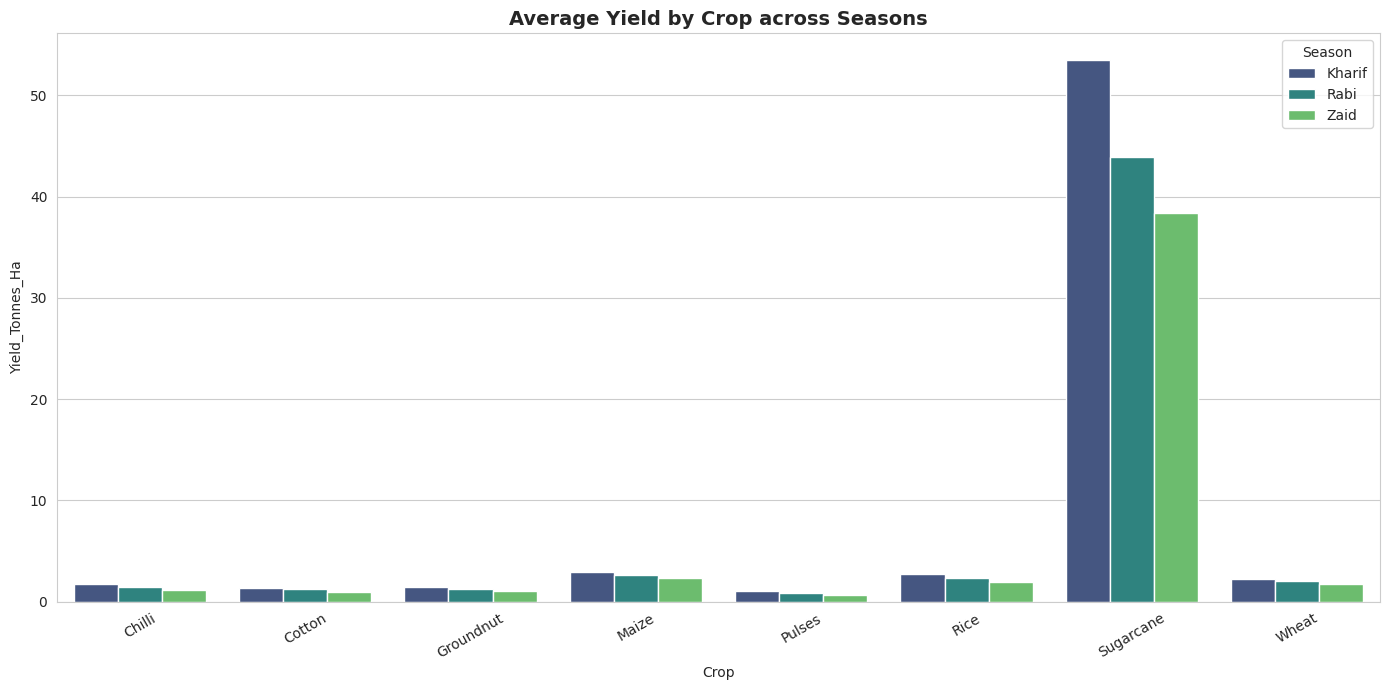

In [ ]:
crop_season_yield = df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=crop_season_yield, x='Crop', y='Yield_Tonnes_Ha', hue='Season', palette='viridis')
plt.title('Average Yield by Crop across Seasons')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('04_crop_season_yield.png', dpi=150)
plt.show()

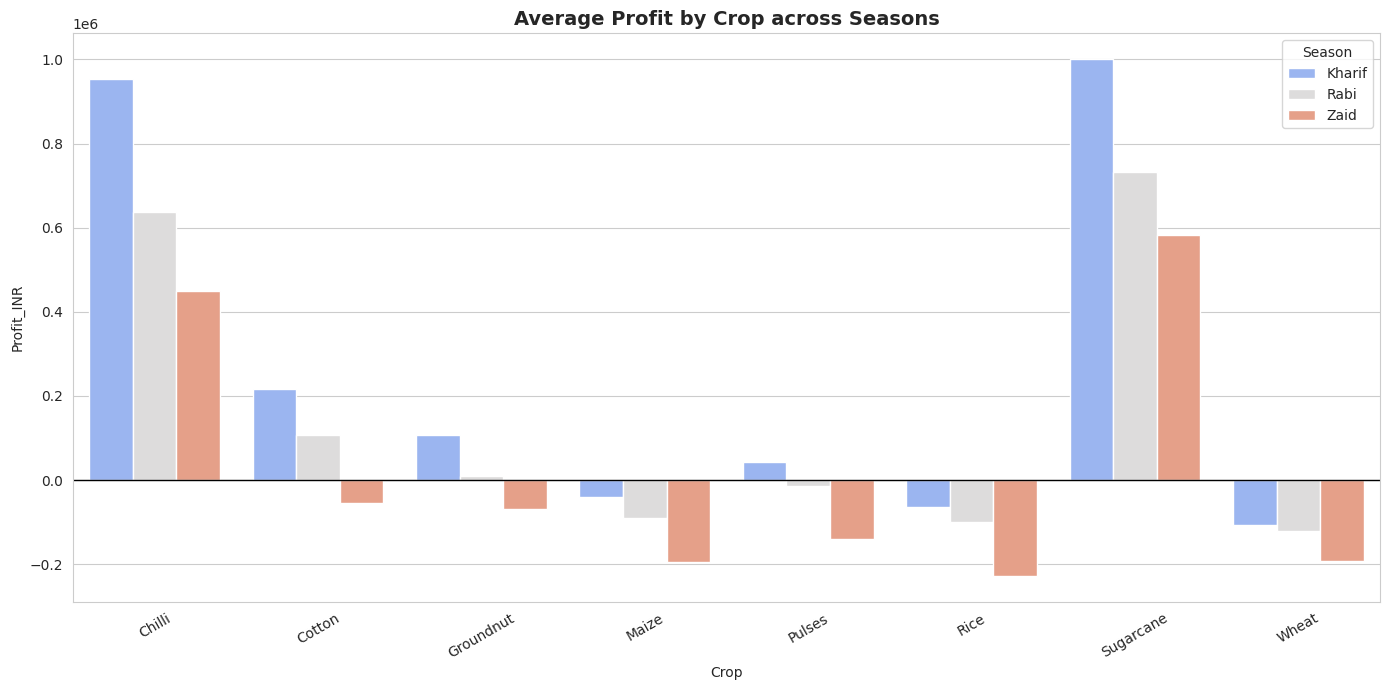

In [ ]:
crop_season_profit = df.groupby(['Season', 'Crop'])['Profit_INR'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=crop_season_profit, x='Crop', y='Profit_INR', hue='Season', palette='coolwarm')
plt.title('Average Profit by Crop across Seasons')
plt.xticks(rotation=30)
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.savefig('05_crop_season_profit.png', dpi=150)
plt.show()

## Yield Distribution & Outliers Across Seasons

/tmp/ipykernel_552/875409287.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='pastel')


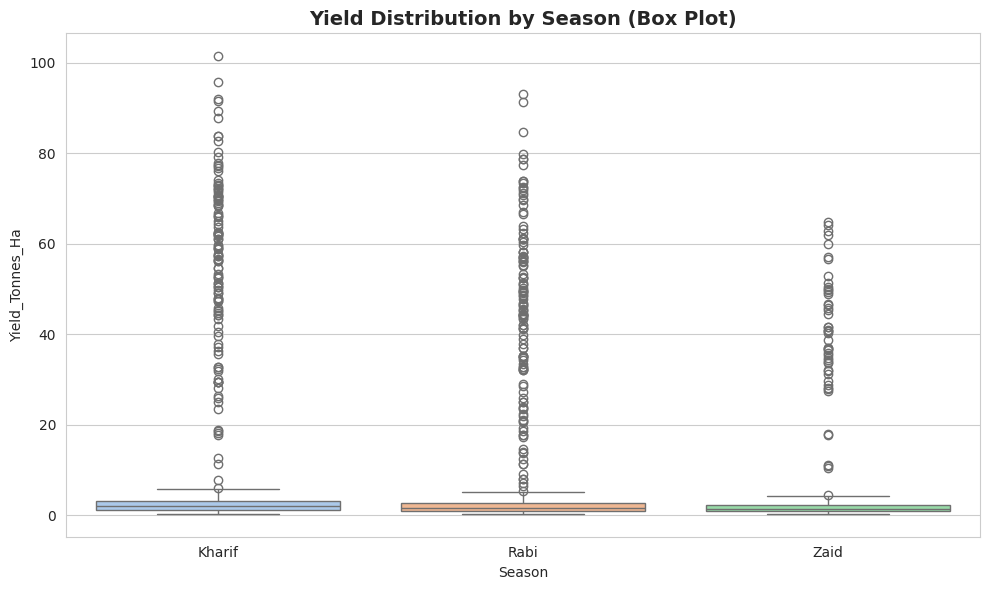

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='pastel')
plt.title('Yield Distribution by Season (Box Plot)')
plt.tight_layout()
plt.savefig('06_yield_boxplot.png', dpi=150)
plt.show()

## Relationships Between Environmental Conditions and Yield/Profit

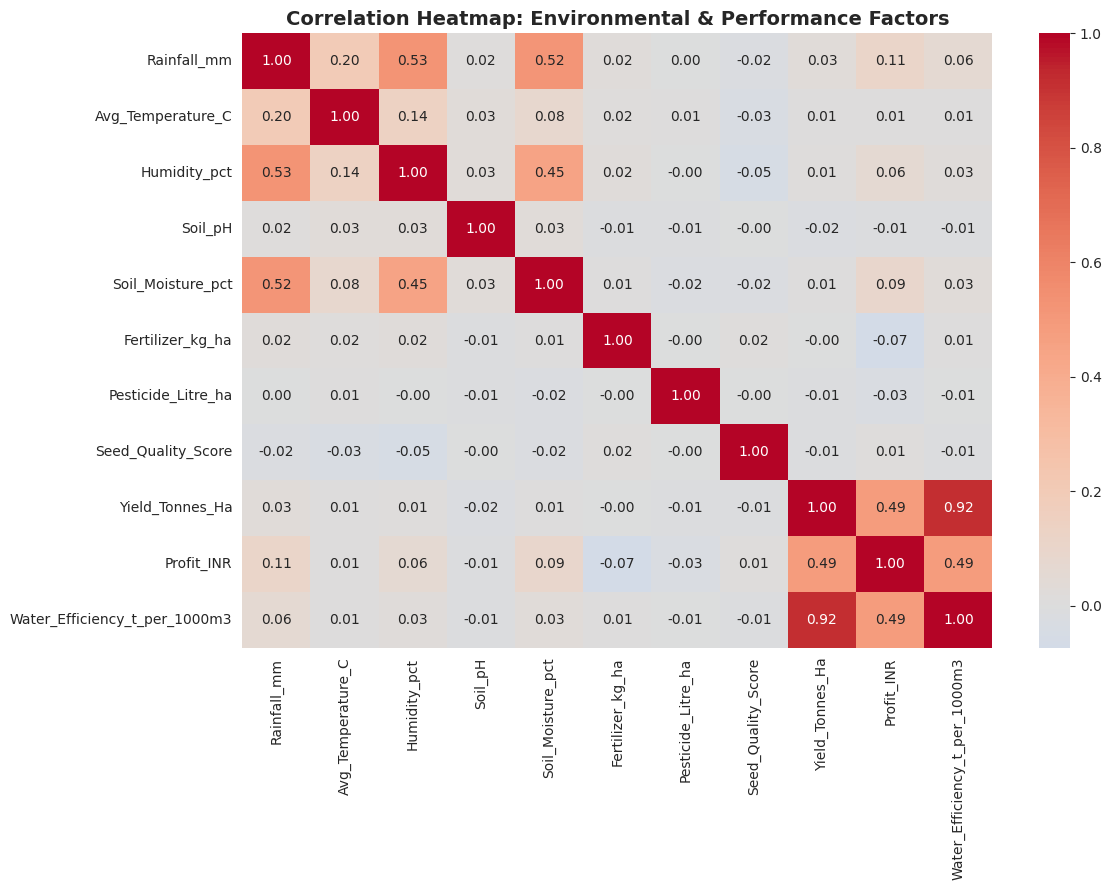

In [ ]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_pH', 'Soil_Moisture_pct',
             'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
             'Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Environmental & Performance Factors')
plt.tight_layout()
plt.savefig('07_correlation_heatmap.png', dpi=150)
plt.show()

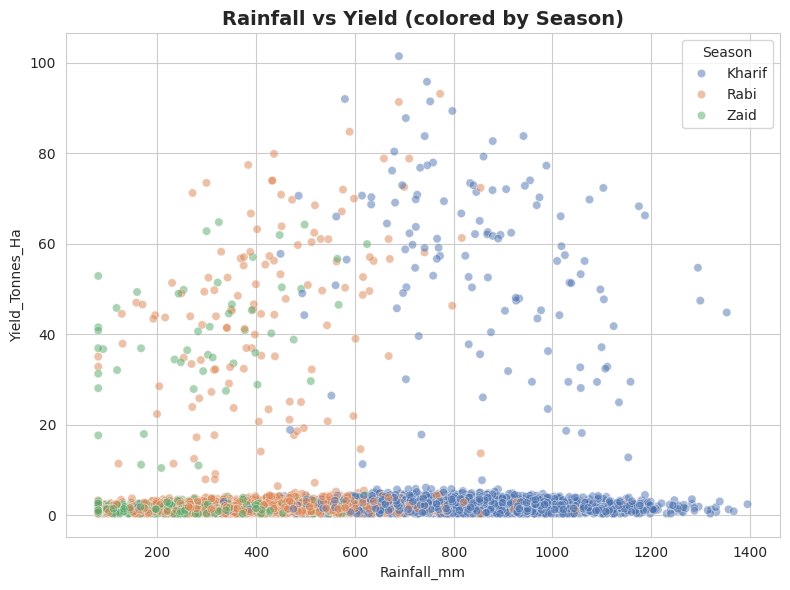

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5, palette='deep')
plt.title('Rainfall vs Yield (colored by Season)')
plt.tight_layout()
plt.savefig('08_rainfall_vs_yield.png', dpi=150)
plt.show()

## Water Efficiency by Irrigation Method, per Season

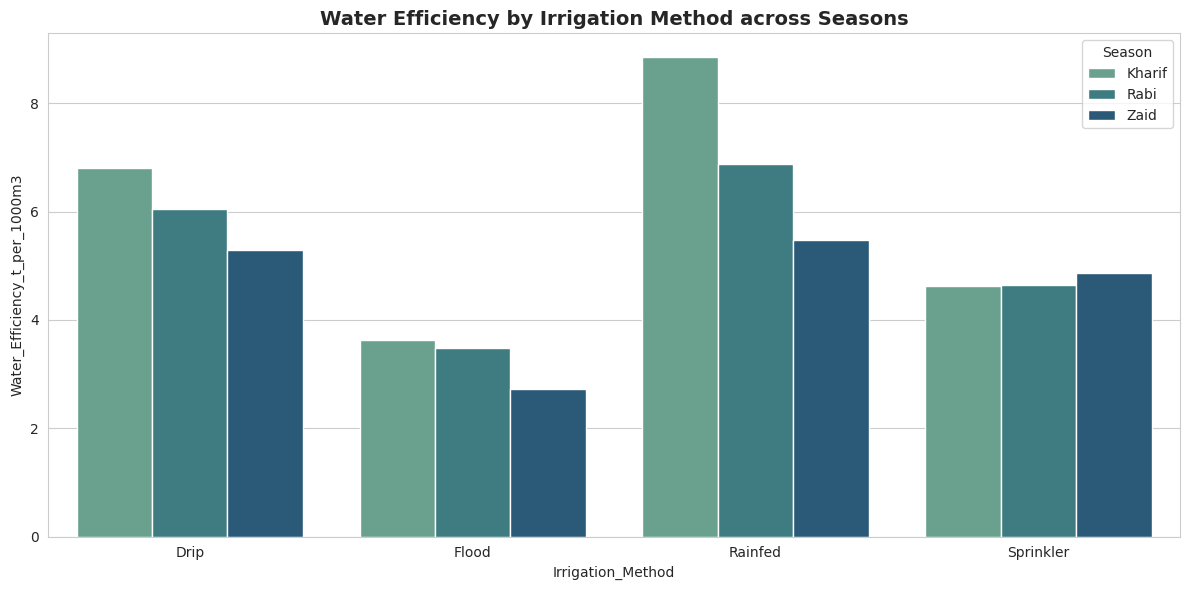

In [ ]:
water_eff = df.groupby(['Season', 'Irrigation_Method'])['Water_Efficiency_t_per_1000m3'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=water_eff, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Season', palette='crest')
plt.title('Water Efficiency by Irrigation Method across Seasons')
plt.tight_layout()
plt.savefig('09_water_efficiency.png', dpi=150)
plt.show()

## State-wise Seasonal Performance

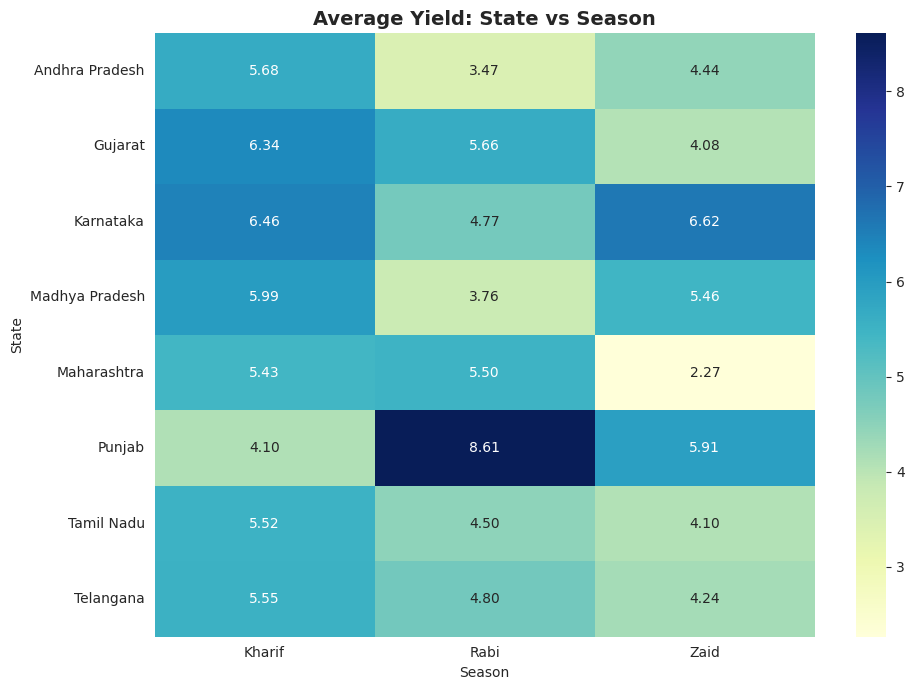

In [ ]:
state_season_yield = df.groupby(['State', 'Season'])['Yield_Tonnes_Ha'].mean().reset_index()
pivot = state_season_yield.pivot(index='State', columns='Season', values='Yield_Tonnes_Ha')

plt.figure(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Average Yield: State vs Season')
plt.tight_layout()
plt.savefig('10_state_season_heatmap.png', dpi=150)
plt.show()

This heatmap shows whether seasonal patterns are consistent across states, or whether some states buck the overall trend.

## Statistical Significance Test

**Hypothesis:**
- H0: Mean yield is the same across all seasons
- H1: At least one season has a different mean yield

In [ ]:
kharif = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = stats.f_oneway(kharif, rabi, zaid)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference in yield across seasons (reject H0)")
else:
    print("Result: No statistically significant difference in yield across seasons at 95% confidence (fail to reject H0)")

F-statistic: 1.4614
P-value: 0.2320
Result: No statistically significant difference in yield across seasons at 95% confidence (fail to reject H0)
